# Individual energy profiles — real vs every method

One panel per curve: the real profile of a single (process, sensor, activity)
execution and, on top of it, what every method predicted for that same curve.
Three curves per process, laid out in a grid of three columns.

Which curves are drawn is not a hand-pick: per process they are the ones the
BEST method — the approach with the lowest Overall realism error in
`03_results.ipynb` — reproduces most faithfully, i.e. its highest-realism
curves. Degenerate curves are excluded first (see `MIN_*` in the config): a flat
zero real profile is trivially matched by everything and shows nothing.

The realism error is the one the individual-profile table reports,
`err_f = |f(pred) - f(real)| / mean|f(real)|` over Sum / Max / Mean / Std /
Roughness, normalised per (process, sensor); Overall is their mean, 0 = perfect.


## 0 · Config

In [1]:

# ── What to read ─────────────────────────────────────────────────────────────
EXPERIMENT = 1        # experiment number; the latest run of it is used
RUN        = None     # None = latest run of EXPERIMENT; or a full directory name
                      # / any substring of one, e.g. 'experiment_1_20260801'
SPLIT      = 'TEST'   # 'TEST' | 'TRAIN' — the split the curves are drawn from

# ── The figure ───────────────────────────────────────────────────────────────
N_PER_PROCESS = 3     # curves drawn per process
N_COLS        = 3     # columns of the grid (a process fills one row when equal)
SAVE_PDF      = 'visuals/individual_profiles_grid.pdf'   # None = do not save

# Identity labels become shuffled numbers, with the SAME seed as 03_results.ipynb,
# so 'Process 4 / Sensor 12 / Activity 7' means the same thing in both.
ANONYMISE = True
ANON_SEED = 20260730

# ── Which method is 'best', and which methods are drawn ──────────────────────
# None = the approach with the lowest Overall realism, ranked exactly as the
# individual-profile table ranks it (median over cells of the per-cell median).
# Or pin one by its DISPLAY name, e.g. 'Step DTW (ours)'.
BEST_METHOD       = None
SHOW_METHODS      = None   # None = every approach in the run; or a list of display names
EXCLUDE_APPROACHES = ['Exemplar (real curve)', 'Exemplar (no DTW)',
                      'Exemplar + DTW (warped)']        # raw names, dropped everywhere

# ── Which curves qualify ─────────────────────────────────────────────────────
# Without these the winners are all degenerate: a real curve that is flat zero
# scores a realism error of exactly 0 for every method, so the top of the ranking
# fills up with empty profiles that show nothing.
MIN_CURVE_POINTS   = 15     # samples in the curve — long enough to have a shape
MIN_REL_STD        = 0.02   # std|real| / max|real| — reject flat lines
MIN_REL_MAGNITUDE  = 0.25   # max|real| relative to the sensor's mean max|real| —
                            # reject curves that are near-zero for their sensor
MIN_DUTY           = 0.10   # mean|real| / max|real| — reject a curve that is zero
                            # except for one spike (there mean/max ~ 1/N): it passes
                            # the two filters above on the spike alone and draws an
                            # empty panel with a needle in it
DIVERSIFY          = 'sensor+activity'   # 'sensor' | 'sensor+activity' | None — at
                                # most one curve per key, so a process does not show
                                # three executions of the same thing. 'sensor' spreads
                                # wider but can cost a lot of realism on the third
                                # panel, when a process has only two sensors the best
                                # method reproduces well.

# ── Metrics behind the ranking (identical to 03_results.ipynb, section I) ────
REALISM_SPECS = {
    'Sum':       ('sum_pred',   'sum_real'),    # total energy over the curve
    'Max':       ('max_pred',   'max_real'),    # peak — sizing and tariffs
    'Mean':      ('mean_pred',  'mean_real'),   # average load level = the bias
    'Std':       ('std_pred',   'std_real'),    # spread — the flatness measure
    'Roughness': ('rough_pred', 'rough_real'),  # jaggedness
}
RANK_MIN_CURVE_POINTS = 5      # curve-length floor used for the RANKING only
LEVEL_CELL_COVERAGE   = True   # rank on the cells every approach is scored on

# Paper naming: the proposed method is 'Step DTW', ablations are named by what was
# removed, the medians by their granularity.
METHOD_RENAME = {
    'Step DTW smooth + ML + Ext.':    'Step DTW (ours)',
    'Step DTW + ML + Ext.':           'Step DTW (step gains)',
    'ML + Ext. Factors':              'Step DTW w/o segments',
    'DTW + ML + Ext. Factors':        'Step DTW w/o segments',
    'ML DTW':                         'Step DTW w/o segments and ext.',
    'DTW + ML':                       'Step DTW w/o segments and ext.',
    'ML only (no DTW)':               'Step DTW w/o DTW',
    'Median per Activity & Sensor':   'Activity median',
    'Median per activity and sensor': 'Activity median',
    'Baseline':                       'Sensor median (baseline)',
    'DTW + Seq2Seq + Ext. Factors':   'Seq2Seq (aligned)',
    'DTW + Seq2Seq':                  'Seq2Seq (aligned, w/o ext.)',
    'Seq2Seq only (no DTW)':          'Seq2Seq (unaligned)',
    'Seq2Seq IOM (DTW-selected)':     'Seq2Seq (IOM)',
}

## 1 · Load the run

In [2]:

# ── Resolve the run and read the per-curve statistics (no curves yet) ─────────
import re
import numpy as np, pandas as pd
import pyarrow.dataset as ds, pyarrow.compute as pc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')

RESULTS_ROOT = Path('..') / 'results'

_runs = sorted((d for d in RESULTS_ROOT.iterdir()
                if d.is_dir() and (d / 'curve_eval_results.parquet').exists()),
               key=lambda d: d.name)
assert _runs, 'no run with curve_eval_results.parquet'

# 'latest' is the latest TIMESTAMP, not the last name alphabetically: a run that
# has been renamed (experiment_1_old_20260730_...) still starts with the same
# experiment prefix and sorts after the newer one, which would silently read a
# superseded run. The name is matched strictly as experiment_<n>_<date>_<time>.
_RUN_RE = re.compile(r'^experiment_(?P<exp>.+?)_(?P<stamp>\d{8}_\d{6})$')

def _stamp(d):
    m = _RUN_RE.match(d.name)
    return m.group('stamp') if m else ''

if RUN:
    _match = [d for d in _runs if d.name == RUN] or [d for d in _runs if RUN in d.name]
    assert _match, f'RUN={RUN!r} matches none of: ' + ', '.join(d.name for d in _runs)
    run_dir = max(_match, key=_stamp)
else:
    _exp = [d for d in _runs
            if (_m := _RUN_RE.match(d.name)) and _m.group('exp') == str(EXPERIMENT)]
    assert _exp, (f'no run named experiment_{EXPERIMENT}_<date>_<time>; '
                  'set RUN explicitly. Available: ' + ', '.join(d.name for d in _runs))
    run_dir = max(_exp, key=_stamp)
print('Run:', run_dir.name)
_other = [d.name for d in _runs if d is not run_dir]
print('     (other runs present: ' + ', '.join(_other) + ')' if _other else '')

# Sample spacing, so the x axis can be minutes instead of sample numbers.
_info = json.loads((run_dir / 'info.json').read_text()) if (run_dir / 'info.json').exists() else {}
_res  = str(_info.get('temporal_resolution', '1min'))
_m    = re.fullmatch(r'(\d+)\s*min', _res)
DT_MIN  = float(_m.group(1)) if _m else None      # None = unknown spacing
X_LABEL = ('minutes since activity start' if DT_MIN
           else f'samples since activity start ({_res})')
print(f'Temporal resolution: {_res}  ->  x axis in ' + ('minutes' if DT_MIN else 'samples'))

# Only the statistics columns — the curves themselves are read later, for the
# handful of instances that end up in the figure (the file holds ~400k of them).
_STAT_COLS = ['Approach', 'Process', 'Sensor', 'Split', 'Activity', 'Instance', 'N',
              'mean_real', 'std_real', 'max_real', 'rough_real',
              'mean_pred', 'std_pred', 'max_pred', 'rough_pred']
stats = pd.read_parquet(run_dir / 'curve_eval_results.parquet', columns=_STAT_COLS)
stats = stats[stats['Split'] == SPLIT]
if EXCLUDE_APPROACHES:
    stats = stats[~stats['Approach'].isin(EXCLUDE_APPROACHES)]
CURVE_KEY = ['Process', 'Sensor', 'Activity', 'Instance']
print(f'{len(stats):,} scored curves | {stats["Approach"].nunique()} approaches | '
      f'{stats.groupby(CURVE_KEY).ngroups:,} distinct curves | '
      f'{stats["Process"].nunique()} processes')

Run: experiment_1_20260801_164745
     (other runs present: 20260427_195021, experiment_1000_20260729_201444, experiment_1_old_20260730_101913, experiment_976_20260726_103126, experiment_988_20260728_163037, experiment_999_20260729_175612)
Temporal resolution: 1min  ->  x axis in minutes
135,473 scored curves | 7 approaches | 19,403 distinct curves | 6 processes


In [3]:

# ── Anonymisation maps, built exactly as 03_results.ipynb builds them ────────
# Same population (this split, exclusions applied), same seeds, same order — so a
# number here is the number the individual-profile table uses.
def _anon_map(values, prefix, seed):
    labels = sorted(pd.Series(values).dropna().astype(str).unique())
    order  = np.random.default_rng(seed).permutation(len(labels)) + 1
    return {lab: f'{prefix} {n}' for lab, n in zip(labels, order)}

ANON = {}
if ANONYMISE:
    _pair = stats['Process'].astype(str) + ' | ' + stats['Sensor'].astype(str)
    ANON['Process']  = _anon_map(stats['Process'],  'Process',  ANON_SEED + 0)
    ANON['Activity'] = _anon_map(stats['Activity'], 'Activity', ANON_SEED + 1)
    ANON['Sensor']   = _anon_map(_pair,             'Sensor',   ANON_SEED + 2)
    print('Anonymised: ' + ', '.join(f'{k} ({len(v)})' for k, v in ANON.items()))

def label_process(p):
    return ANON['Process'][str(p)] if ANONYMISE else str(p)

def label_activity(a):
    return ANON['Activity'][str(a)] if ANONYMISE else str(a)

def label_sensor(p, s):
    return ANON['Sensor'][f'{p} | {s}'] if ANONYMISE else str(s)

# The unit survives anonymisation — it is a property of the signal, not an identity.
_UNITS = ['kg/h', 'g/kg', 'l/h', 'kWh', 'kW', 'm3/h', 'bar', 'kg', '%']
def sensor_unit(sensor):
    s = str(sensor)
    body = s[:-len('_energy_to_model')] if s.endswith('_energy_to_model') else s
    for u in _UNITS:
        if re.search(rf'(^|[_\W]){re.escape(u)}($|[_\W])', body, flags=re.I):
            return u
    if re.search(r'temp', body, flags=re.I):
        return '\u00b0C'
    return 'value'

Anonymised: Process (6), Activity (29), Sensor (79)


## 2 · Realism per curve, and the best method

In [4]:

# ── The realism error of every (curve, approach), then the approach ranking ──
# err_f = |f(pred) - f(real)| / mean|f(real)| of that (process, sensor), so the
# five features are comparable and 0 is a perfect reproduction. The SCALE is the
# sensor's typical magnitude over the whole run, not this curve's own — dividing
# by the curve itself would make a tiny curve unmissable and a large one easy.
for _side in ('real', 'pred'):
    stats[f'sum_{_side}'] = stats[f'mean_{_side}'] * stats['N']

_uniq = stats.drop_duplicates(['Process', 'Sensor', 'Instance', 'Activity'])
for _name, (_num, _den) in REALISM_SPECS.items():
    _by = (_uniq.groupby(['Process', 'Sensor'])[_den]
                .apply(lambda s: pd.to_numeric(s, errors='coerce').abs().mean()))
    _scale = (pd.MultiIndex.from_arrays([stats['Process'], stats['Sensor']])
                .map(_by).to_numpy(dtype=float))
    stats[_name] = np.where(np.isfinite(_scale) & (_scale > 1e-6),
                            (stats[_num] - stats[_den]).abs() / _scale, np.nan)

METRICS = [m for m in REALISM_SPECS if stats[m].notna().any()]
stats['Overall'] = stats[METRICS].mean(axis=1)
print('Realism metrics:', METRICS)

# The ranking population: the same levelling the table uses, so the method called
# best here is the method the table calls best.
CELL_KEY = ['Process', 'Activity', 'Sensor']
_rank = stats[stats['N'] >= RANK_MIN_CURVE_POINTS]
if LEVEL_CELL_COVERAGE:
    _cells = {a: set(map(tuple, g[CELL_KEY].drop_duplicates().to_numpy()))
              for a, g in _rank.groupby('Approach')}
    _shared = set.intersection(*_cells.values()) if _cells else set()
    _rank = _rank[_rank[CELL_KEY].apply(tuple, axis=1).isin(_shared)]
    print(f'Ranked on the {len(_shared)} (process, activity, sensor) cells every '
          f'approach is scored on')

_combo = _rank.groupby(CELL_KEY + ['Approach'])[METRICS].median().reset_index()
_combo['Overall'] = _combo[METRICS].mean(axis=1)
ranking = (_combo.groupby('Approach')[METRICS + ['Overall']].median()
                 .sort_values('Overall')
                 .rename(index=METHOD_RENAME).round(3))
stats['Method'] = stats['Approach'].replace(METHOD_RENAME)

if BEST_METHOD is None:
    BEST_METHOD = ranking.index[0]
assert BEST_METHOD in set(stats['Method']), \
    f'{BEST_METHOD!r} is not in this run: {sorted(set(stats["Method"]))}'
print(f'\nBest method: {BEST_METHOD}   (lowest Overall realism error)\n')
display(ranking)

Realism metrics: ['Sum', 'Max', 'Mean', 'Std', 'Roughness']


Ranked on the 390 (process, activity, sensor) cells every approach is scored on

Best method: Step DTW (ours)   (lowest Overall realism error)



,Sum,Max,Mean,Std,Roughness,Overall
Approach,,,,,,
Step DTW (ours),0.017,0.065,0.046,0.373,0.467,0.229
Step DTW w/o DTW,0.018,0.072,0.050,0.424,0.542,0.278
Activity median,0.015,0.062,0.043,0.416,0.534,0.280
Step DTW w/o segments,0.017,0.064,0.051,0.428,0.530,0.284
Sensor median (baseline),0.015,0.068,0.042,0.473,0.583,0.291
Seq2Seq (IOM),0.020,0.083,0.061,0.565,0.655,0.334
Seq2Seq (aligned),0.018,0.080,0.057,0.592,0.670,0.334


## 3 · The curves to draw

In [5]:

# ── Per process: the curves BEST_METHOD reproduces most faithfully ───────────
# The candidate pool is filtered first. A real profile that is flat, or ~zero for
# its sensor, is matched perfectly by every method — those curves top the ranking
# without showing anything, so they are not eligible.
_best = stats[stats['Method'] == BEST_METHOD].copy()
_sensor_scale = (_uniq.groupby(['Process', 'Sensor'])['max_real']
                      .apply(lambda s: s.abs().mean()))
_best['rel_magnitude'] = (_best['max_real'].abs().to_numpy() /
                          pd.MultiIndex.from_arrays([_best['Process'], _best['Sensor']])
                            .map(_sensor_scale).to_numpy(dtype=float))
_best['rel_std'] = _best['std_real'].abs() / _best['max_real'].abs().replace(0, np.nan)
_best['duty']    = _best['mean_real'].abs() / _best['max_real'].abs().replace(0, np.nan)

_pool = _best[(_best['N'] >= MIN_CURVE_POINTS)
              & (_best['max_real'].abs() > 1e-6)
              & (_best['rel_std'] >= MIN_REL_STD)
              & (_best['rel_magnitude'] >= MIN_REL_MAGNITUDE)
              & (_best['duty'] >= MIN_DUTY)
              & _best['Overall'].notna()]
print(f'Candidate curves after the filters: {len(_pool):,} of {len(_best):,}')

_DIV_KEY = {'sensor': ['Sensor'], 'sensor+activity': ['Sensor', 'Activity'],
            None: None, 'none': None}[DIVERSIFY]

_rows = []
for _proc, _g in _pool.groupby('Process', sort=True):
    _taken, _seen = [], set()
    for _, _r in _g.sort_values('Overall').iterrows():
        if _DIV_KEY:
            _k = tuple(_r[c] for c in _DIV_KEY)
            if _k in _seen:
                continue
            _seen.add(_k)
        _taken.append(_r)
        if len(_taken) == N_PER_PROCESS:
            break
    if len(_taken) < N_PER_PROCESS:      # diversity before completeness: refill
        for _, _r in _g.sort_values('Overall').iterrows():   # from what is left
            if any(_r.name == t.name for t in _taken):
                continue
            _taken.append(_r)
            if len(_taken) == N_PER_PROCESS:
                break
    if len(_taken) < N_PER_PROCESS:
        print(f'  {_proc}: only {len(_taken)} curve(s) pass the filters')
    _rows += _taken

selected = pd.DataFrame(_rows).reset_index(drop=True)
selected['Process label']  = selected['Process'].map(label_process)
selected['Sensor label']   = [label_sensor(p, s) for p, s in
                              zip(selected['Process'], selected['Sensor'])]
selected['Activity label'] = selected['Activity'].map(label_activity)
selected['Unit']           = selected['Sensor'].map(sensor_unit)

print(f'\n{len(selected)} curves selected — realism of {BEST_METHOD} on each:')
display(selected[['Process label', 'Sensor label', 'Activity label', 'Instance',
                  'N', 'Unit', 'Overall'] + METRICS]
        .rename(columns={'Overall': 'Realism'}).round(3))

Candidate curves after the filters: 4,299 of 19,345

18 curves selected — realism of Step DTW (ours) on each:


,Process label,Sensor label,Activity label,Instance,N,Unit,Realism,Sum,Max,Mean,Std,Roughness
0,Process 3,Sensor 25,Activity 5,8,15,kW,0.019,0.003,0.008,0.002,0.016,0.068
1,Process 3,Sensor 25,Activity 25,6,29,kW,0.026,0.019,0.004,0.007,0.053,0.048
2,Process 3,Sensor 25,Activity 16,28,16,kW,0.028,0.001,0.003,0.001,0.087,0.049
3,Process 6,Sensor 16,Activity 11,42,37,kg/h,0.049,0.014,0.115,0.015,0.066,0.035
4,Process 6,Sensor 53,Activity 11,84,58,kW,0.049,0.045,0.076,0.030,0.075,0.019
5,Process 6,Sensor 53,Activity 23,8,46,kW,0.067,0.032,0.072,0.028,0.139,0.065
6,Process 1,Sensor 69,Activity 11,18,58,kW,0.020,0.042,0.003,0.041,0.008,0.006
7,Process 1,Sensor 71,Activity 11,39,32,kg/h,0.024,0.012,0.005,0.021,0.014,0.068
8,Process 1,Sensor 71,Activity 23,7,39,kg/h,0.138,0.060,0.091,0.088,0.231,0.221
9,Process 4,Sensor 67,Activity 29,95,160,g/kg,0.028,0.001,0.039,0.001,0.045,0.052


In [6]:

# ── Read the actual curves, for the selected instances only ──────────────────
# Both files carry one row per (process, sensor, activity, instance) — the
# predictions per approach, the real curve once — and every prediction is on the
# real curve's own grid, so a point index means the same time in all of them.
_pred_ds = ds.dataset(run_dir / 'curve_eval_results.parquet')
_real_ds = ds.dataset(run_dir / 'real_test_curves.parquet')

_filter = None
for _proc, _g in selected.groupby('Process'):
    _f = (pc.field('Process') == _proc) & pc.field('Instance').isin(
        [int(i) for i in _g['Instance'].unique()])
    _filter = _f if _filter is None else (_filter | _f)
_filter = _filter & (pc.field('Split') == SPLIT)

_pred = (_pred_ds.to_table(filter=_filter,
                           columns=CURVE_KEY + ['Approach', 'N', 'y_pred'])
                 .to_pandas())
_real = (_real_ds.to_table(filter=_filter, columns=CURVE_KEY + ['N', 'y_real'])
                 .to_pandas())
if EXCLUDE_APPROACHES:
    _pred = _pred[~_pred['Approach'].isin(EXCLUDE_APPROACHES)]
_pred['Method'] = _pred['Approach'].replace(METHOD_RENAME)

# The filter is a coarse (process, instance) net — keep the exact curves only.
_want = set(map(tuple, selected[CURVE_KEY].to_numpy()))
_pred = _pred[_pred[CURVE_KEY].apply(tuple, axis=1).isin(_want)]
_real = _real[_real[CURVE_KEY].apply(tuple, axis=1).isin(_want)]

CURVES = {}          # (process, sensor, activity, instance) -> {series -> array}
for _k, _g in _real.groupby(CURVE_KEY):
    CURVES[_k] = {'Real': np.asarray(_g.iloc[0]['y_real'], dtype=float)}
for _k, _g in _pred.groupby(CURVE_KEY):
    CURVES.setdefault(_k, {}).update(
        {r['Method']: np.asarray(r['y_pred'], dtype=float) for _, r in _g.iterrows()})

_missing = [k for k in _want if 'Real' not in CURVES.get(k, {})]
if _missing:
    print(f'!! no real curve for {len(_missing)} selection(s): {_missing}')
print(f'Loaded {len(CURVES)} curves | methods per curve: '
      f'{sorted({len(v) - 1 for v in CURVES.values()})}')

METHODS_PRESENT = [m for m in ranking.index if m in set(_pred['Method'])]
DRAW_METHODS = ([m for m in SHOW_METHODS if m in METHODS_PRESENT] if SHOW_METHODS
                else METHODS_PRESENT)
DRAW_METHODS = [BEST_METHOD] + [m for m in DRAW_METHODS if m != BEST_METHOD]
print('Methods drawn:', DRAW_METHODS)

Loaded 18 curves | methods per curve: [7]
Methods drawn: ['Step DTW (ours)', 'Step DTW w/o DTW', 'Activity median', 'Step DTW w/o segments', 'Sensor median (baseline)', 'Seq2Seq (IOM)', 'Seq2Seq (aligned)']


## 4 · The grid

In [7]:

# ── Style ────────────────────────────────────────────────────────────────────
# Okabe-Ito, colour-blind safe, in an order whose adjacent pairs clear the CVD
# separation check. Real is the only black, heavy, filled line, so the reference
# is unmistakable; the best method is the only other solid one; the remaining
# methods are thin and dashed, each with its own dash pattern, so identity never
# rests on hue alone (the palette's lighter hues fall below 3:1 on white).
plt.rcParams.update(plt.rcParamsDefault)

_PALETTE = ['#D55E00', '#0072B2', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#666666']
_DASHES  = [(4, 1.6), (1.4, 1.4), (5, 1.5, 1.2, 1.5), (3, 1.2, 1.2, 1.2),
            (6, 1.8), (1, 1.5)]

REAL_STYLE = dict(color='black', linestyle='-', linewidth=2.0, zorder=10)
_style = {BEST_METHOD: dict(color=_PALETTE[0], linestyle='-', linewidth=1.7,
                            alpha=0.95, zorder=9)}
for _i, _m in enumerate([m for m in DRAW_METHODS if m != BEST_METHOD]):
    _style[_m] = dict(color=_PALETTE[1 + _i % (len(_PALETTE) - 1)],
                      linestyle=(0, _DASHES[_i % len(_DASHES)]),
                      linewidth=1.1, alpha=0.85, zorder=8 - _i)
SERIES_STYLE = _style

FS = {'suptitle': 14, 'legend': 11, 'row': 12, 'title': 10, 'axis': 9, 'tick': 8,
      'note': 8}

def draw_panel(ax, key, row):
    """One curve: the real profile filled in black, every method over it."""
    series = CURVES.get(key, {})
    real = series.get('Real')
    if real is None or len(real) == 0:
        ax.text(0.5, 0.5, 'no real curve', ha='center', va='center',
                transform=ax.transAxes, fontsize=FS['note'], color='#888888')
        ax.set_xticks([]); ax.set_yticks([])
        return

    def _x(v):
        return np.arange(len(v)) * (DT_MIN if DT_MIN else 1.0)

    drawn = [real]
    ax.plot(_x(real), real, label='Real', **REAL_STYLE)
    for m in DRAW_METHODS:
        v = series.get(m)
        if v is None or len(v) == 0:
            continue
        ax.plot(_x(v), v, label=m, **SERIES_STYLE[m])
        drawn.append(v)

    # The y range spans EVERY series, never just the real one: a method that
    # predicts far off the real level has to stay visible, that is the error the
    # panel is about. Zero is not forced into the range — a temperature that
    # lives between 18 and 22 would spend the whole panel on empty axis — so the
    # real curve is only filled when its baseline is genuinely 0.
    _lo = min(float(np.nanmin(v)) for v in drawn)
    _hi = max(float(np.nanmax(v)) for v in drawn)
    _pad = 0.06 * (_hi - _lo) if _hi > _lo else max(abs(_hi), 1.0) * 0.06
    ax.set_ylim(_lo - _pad, _hi + _pad)
    if _lo >= 0 and _lo <= 0.15 * _hi:                 # signal returns to zero
        ax.fill_between(_x(real), real, color='black', alpha=0.06, zorder=0)

    ax.set_title(f'{row["Sensor label"]} — {row["Activity label"]}\n'
                 f'curve {int(row["Instance"])}, {int(row["N"])} points  ·  '
                 f'realism {row["Overall"]:.3f}',
                 fontsize=FS['title'], fontweight='bold', linespacing=1.4)
    ax.set_ylabel(row['Unit'], fontsize=FS['axis'])
    ax.set_xlabel(X_LABEL, fontsize=FS['axis'])
    ax.tick_params(labelsize=FS['tick'])
    ax.margins(x=0.01)
    ax.grid(alpha=0.15, linewidth=0.6)
    for _s in ('top', 'right'):
        ax.spines[_s].set_visible(False)

Saved: visuals/individual_profiles_grid.pdf


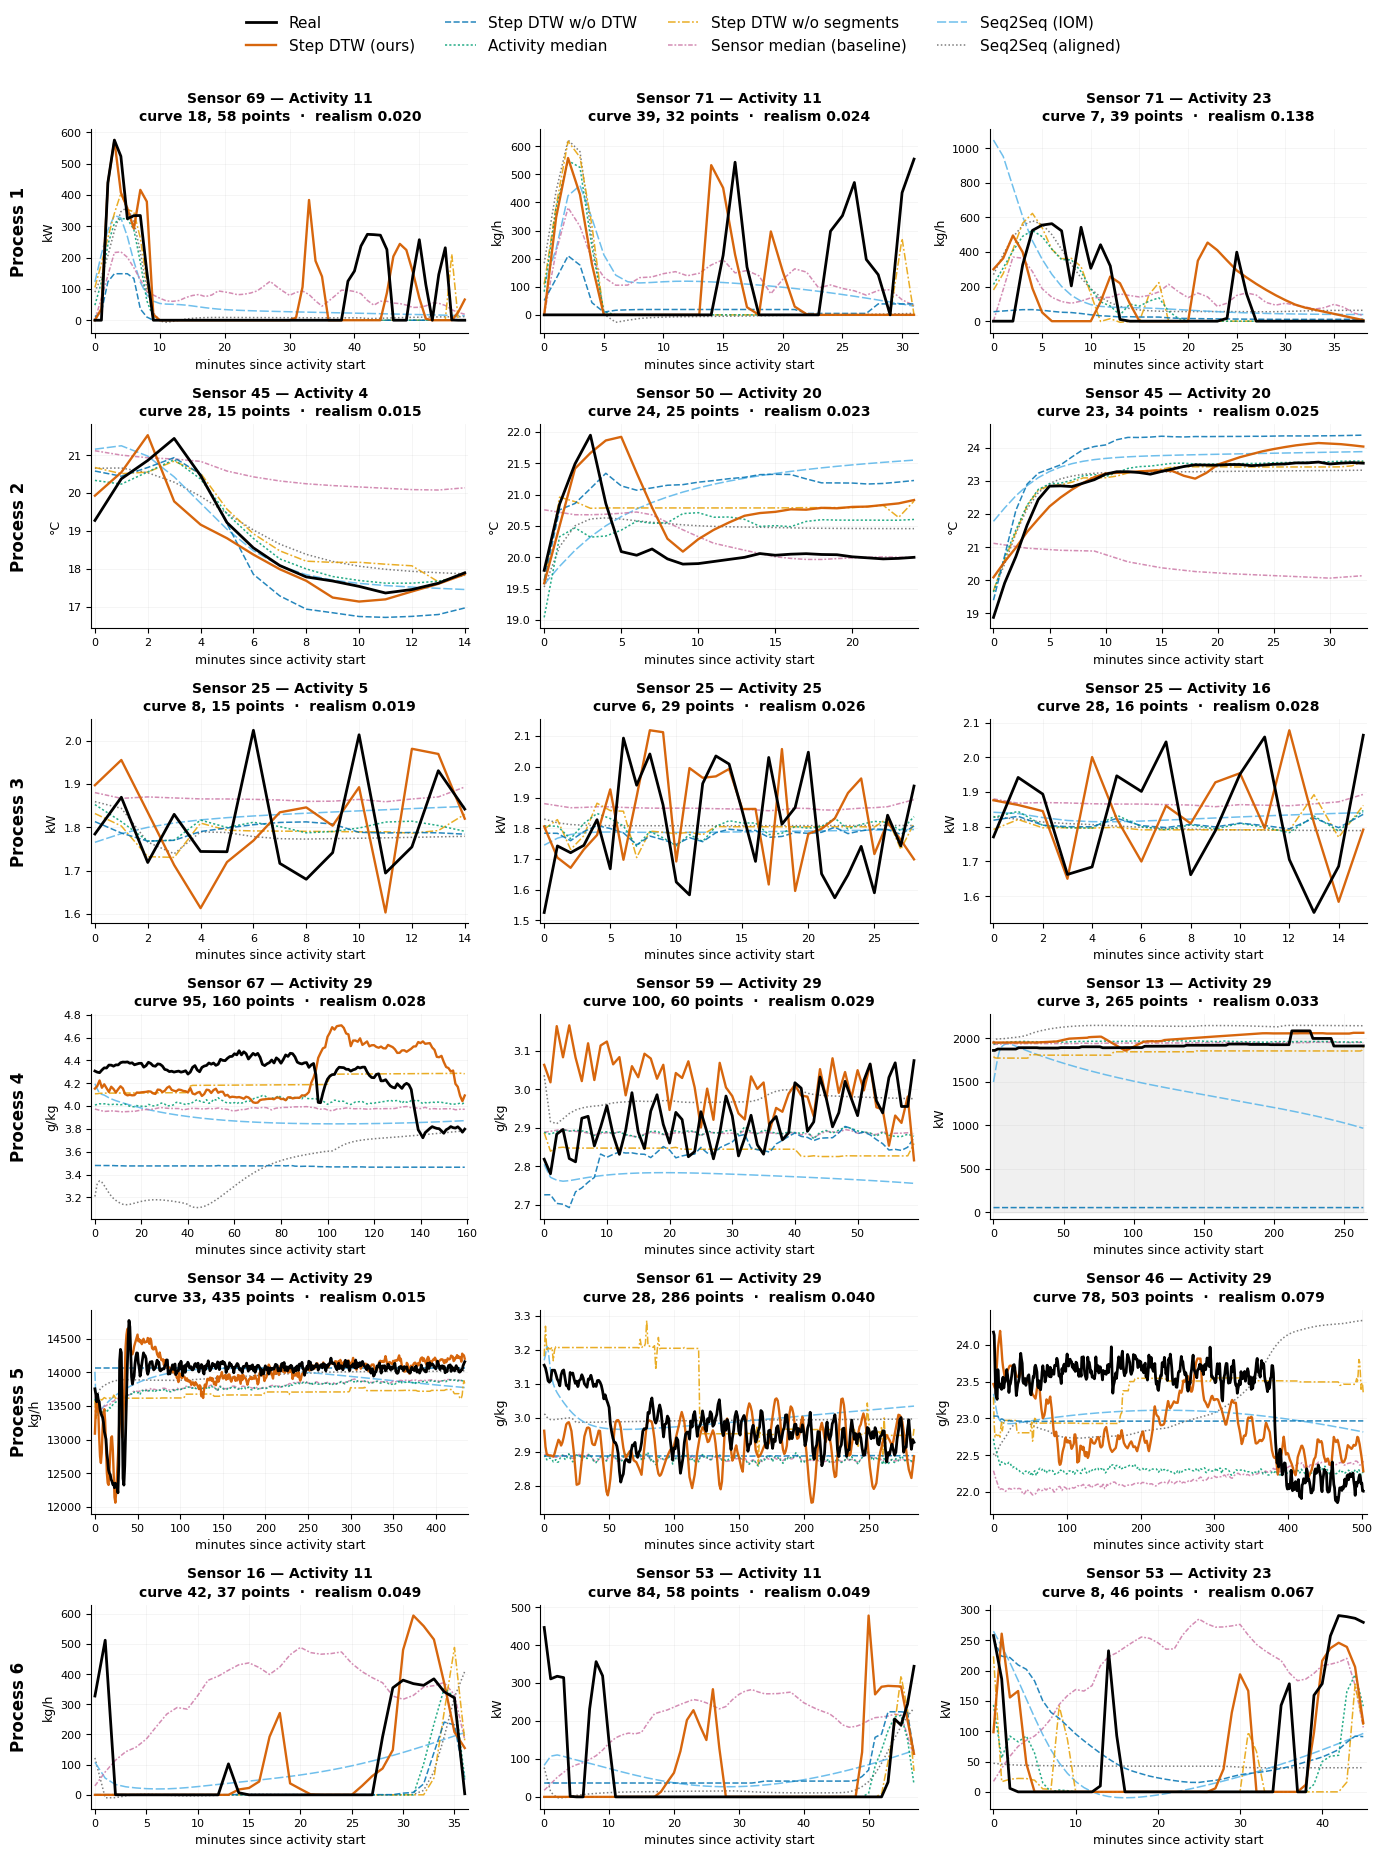

In [8]:

# ── Layout: one row per process, N_COLS panels wide ──────────────────────────
# Rows follow the DISPLAYED process order, so an anonymised figure reads
# Process 1, 2, 3, ... top to bottom instead of in raw-name order.
_procs = sorted(dict.fromkeys(selected['Process']),
                key=lambda p: [int(t) if t.isdigit() else t
                               for t in re.split(r'(\d+)', label_process(p))])
_by_proc = {p: g.reset_index(drop=True) for p, g in selected.groupby('Process')}
_rows_per_proc = int(np.ceil(N_PER_PROCESS / N_COLS))
_nrows = len(_procs) * _rows_per_proc

fig, axes = plt.subplots(_nrows, N_COLS, figsize=(4.7 * N_COLS, 3.1 * _nrows))
axes = np.atleast_2d(axes)

for _pi, _proc in enumerate(_procs):
    _g = _by_proc[_proc]
    for _j in range(_rows_per_proc * N_COLS):
        _ax = axes[_pi * _rows_per_proc + _j // N_COLS, _j % N_COLS]
        if _j < len(_g):
            draw_panel(_ax, tuple(_g.loc[_j, CURVE_KEY]), _g.loc[_j])
        else:
            _ax.axis('off')
    # Process name once per row, to the left of its first panel.
    _first = axes[_pi * _rows_per_proc, 0]
    _first.annotate(label_process(_proc), xy=(0, 0.5), xycoords='axes fraction',
                    xytext=(-52, 0), textcoords='offset points', rotation=90,
                    ha='center', va='center', fontsize=FS['row'], fontweight='bold')

handles = ([Line2D([0], [0], label='Real', **REAL_STYLE)] +
           [Line2D([0], [0], label=m, **SERIES_STYLE[m]) for m in DRAW_METHODS])
fig.legend(handles=handles, labels=[h.get_label() for h in handles],
           loc='upper center', ncol=min(4, len(handles)), frameon=False,
           fontsize=FS['legend'], bbox_to_anchor=(0.5, 1.0))

_leg_rows = int(np.ceil(len(handles) / min(4, len(handles))))
fig.tight_layout(rect=[0.012, 0, 1, 1 - 0.020 * _leg_rows])

if SAVE_PDF:
    Path(SAVE_PDF).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_PDF, format='pdf', bbox_inches='tight', dpi=300, facecolor='white')
    print('Saved:', SAVE_PDF)
plt.show()

---

### Reading the figure

Every panel is one execution of one activity on one sensor, on its own scale —
the point is the *shape*, not a comparison of levels between panels. `realism`
in the corner is the Overall realism error of the best method on that curve, the
number the curve was selected on; the other methods' errors for the same curves
are in the table below.


In [9]:

# ── The same curves, scored for every method ─────────────────────────────────
# The figure shows the best method at its best; this says what the other methods
# did on exactly those curves — the visual gap, as a number.
_sel_keys = set(map(tuple, selected[CURVE_KEY].to_numpy()))
_all = stats[stats[CURVE_KEY].apply(tuple, axis=1).isin(_sel_keys)].copy()
_all['Curve'] = [f'{label_process(p)} · {label_sensor(p, s)} · {label_activity(a)} #{i}'
                 for p, s, a, i in _all[CURVE_KEY].to_numpy()]

_wide = (_all.pivot_table(index='Curve', columns='Method', values='Overall')
             .reindex(columns=[m for m in ranking.index if m in set(_all['Method'])]))
display(_wide.round(3).style
        .background_gradient(cmap='Blues_r', axis=1)
        .format('{:.3f}', na_rep='-')
        .set_caption(f'Overall realism error per curve and method ({SPLIT}); '
                     f'0 = perfect, lower is better'))
print('Median over the drawn curves:')
display(_wide.median().round(3).to_frame('Overall realism'))

Method,Step DTW (ours),Step DTW w/o DTW,Activity median,Step DTW w/o segments,Sensor median (baseline),Seq2Seq (IOM),Seq2Seq (aligned)
Curve,,,,,,,
Process 1 · Sensor 69 · Activity 11 #18,0.020,0.756,0.518,0.381,0.480,0.459,0.467
Process 1 · Sensor 71 · Activity 11 #39,0.024,0.465,0.209,0.141,0.285,0.261,0.190
Process 1 · Sensor 71 · Activity 23 #7,0.138,0.611,0.151,0.116,0.284,0.349,0.204
Process 2 · Sensor 45 · Activity 20 #23,0.025,0.031,0.069,0.078,0.315,0.203,0.086
Process 2 · Sensor 45 · Activity 4 #28,0.015,0.173,0.152,0.186,0.514,0.155,0.259
Process 2 · Sensor 50 · Activity 20 #24,0.023,0.165,0.165,0.207,0.210,0.125,0.240
Process 3 · Sensor 25 · Activity 16 #28,0.028,0.149,0.142,0.136,0.156,0.154,0.156
Process 3 · Sensor 25 · Activity 25 #6,0.026,0.147,0.133,0.126,0.158,0.155,0.154
Process 3 · Sensor 25 · Activity 5 #8,0.019,0.111,0.103,0.101,0.117,0.107,0.101


Median over the drawn curves:


,Overall realism
Method,
Step DTW (ours),0.028
Step DTW w/o DTW,0.266
Activity median,0.222
Step DTW w/o segments,0.196
Sensor median (baseline),0.300
Seq2Seq (IOM),0.217
Seq2Seq (aligned),0.242
